In [ ]:
#@title Instalación
#@title Instalación
!pip install dandi
!dandi download https://gui.dandiarchive.org/#/dandiset/000128
!pip install pynwb h5py


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.8/395.8 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.6/118.6 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.9/86.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.9/341.9 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 110.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130

#0. Configuración inicial

In [ ]:
#@title 0.1 Librerias
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from collections import Counter
from scipy.ndimage import gaussian_filter1d
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


In [ ]:
#@title 0.2 Paletas y Path

#Paletas
C = {
    'bg':     '#0d1117',
    'panel':  '#161b22',
    'border': '#30363d',
    'teal':   '#39d0c8',
    'amber':  '#f0a500',
    'red':    '#e05c5c',
    'blue':   '#58a6ff',
    'gray':   '#8b949e',
    'white':  '#e6edf3',
}

plt.rcParams.update({
    'figure.facecolor':  C['bg'],
    'axes.facecolor':    C['panel'],
    'axes.edgecolor':    C['border'],
    'axes.labelcolor':   C['white'],
    'xtick.color':       C['gray'],
    'ytick.color':       C['gray'],
    'text.color':        C['white'],
    'grid.color':        C['border'],
    'grid.linewidth':    0.6,
    'font.family':       'monospace',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

OUT = '/content/eda_outputs'
os.makedirs(OUT, exist_ok=True)

#Path
PATH = '/content/000128/sub-Jenkins/sub-Jenkins_ses-full_desc-train_behavior+ecephys.nwb'

f_data = h5py.File(PATH, 'r')


# 1. Pre-procesamiento

In [ ]:
#@title 1.1 Enventanamiento

#Trials'  time info
target_on = f_data['intervals/trials/target_on_time'][()]  #Inicio de planificación
go_cue = f_data['intervals/trials/go_cue_time'][()]  #Señal de iniciar movimiento
move_onset  = f_data['intervals/trials/move_onset_time'][()] #Inicio del movimiento

#índices de trials válidos
delay = f_data['intervals/trials/delay'][()]
valid_idx = np.where(delay >= 400)[0] #índices de los trials válidos

print(f"Trials totales          : {len(delay)}")
print(f"Trials válidos (>=400ms): {len(valid_idx)}")
print(f"Trials descartados      : {len(delay) - len(valid_idx)}")

#Filtro de data válida
delay_valid = delay[valid_idx]
target_on_valid  = target_on[valid_idx]   #Tiempo de inicio de planificación, válidos
go_cue_valid     = go_cue[valid_idx]      #Tiempo de fin de planificación, válidos
move_onset_valid = move_onset[valid_idx]  #Tiempo de inicio de movimiento, válidos

print("\n")

#Mostrar resultad
df = pd.DataFrame({
    'target_on (s)' : target_on_valid[:8],
    'delay (s)'     : delay_valid[:8]/1000,
    'go_cue (s)'    : go_cue_valid[:8],
    'Reaction(s)'   : move_onset_valid[:8] - go_cue_valid[:8],
    'move_onset (s)': move_onset_valid[:8],
})

print(df.T.to_string())



Trials totales          : 2295
Trials válidos (>=400ms): 1967
Trials descartados      : 328


                    0      1      2       3       4       5       6       7
target_on (s)   0.880  4.291  7.471  10.853  13.687  16.415  19.520  23.007
delay (s)       0.598  0.448  0.498   0.482   0.548   0.765   0.881   0.832
go_cue (s)      1.478  4.739  7.969  11.335  14.235  17.180  20.401  23.839
Reaction(s)     0.427  0.541  0.377   0.417   0.272   0.319   0.433   0.392
move_onset (s)  1.905  5.280  8.346  11.752  14.507  17.499  20.834  24.231


In [ ]:
#@title 1.2. Extracción de neuronas

#Extraer data
spike_times       = f_data['units/spike_times'][()] #Tiempo de spike de cada neurona
spike_idx = f_data['units/spike_times_index'][()] #idx donde termina una neurona e inicia otra


#Parámetros
BIN_SIZE  = 0.001   # 1ms
N_BINS    = 400     # 400ms
N_NEURONS = 182
N_TRIALS  = len(valid_idx)

#Sperar spikes por neurona
neuron_spikes = []
for k in range(N_NEURONS):
    start_k = spike_idx[k-1] if k > 0 else 0
    end_k   = spike_idx[k]
    neuron_spikes.append(spike_times[start_k:end_k])

#Representación
print(f"{'Neurona':>8}  {'Spikes totales':>15}  {'Spikes en ventana de 400ms':>18}")
print("─" * 55)
for k in range(8):
    total = len(neuron_spikes[k])
    en_ventana = 0
    for i in valid_idx:
        t_start = go_cue[i] - 0.400
        t_end   = go_cue[i]
        mask    = (neuron_spikes[k] >= t_start) & (neuron_spikes[k] < t_end)
        en_ventana += mask.sum()
    print(f"{k:>8}  {total:>15}  {en_ventana:>18}")



 Neurona   Spikes totales  Spikes en ventana de 400ms
───────────────────────────────────────────────────────
       0             5811                 712
       1             6522                 200
       2             4276                 134
       3             1545                 243
       4            12141                1773
       5             3950                 398
       6            12087                1413
       7            12592                1868


Shape tensor binario : (1967, 400, 182)
Densidad de spikes   : 0.268%
Total spikes en X    : 383431




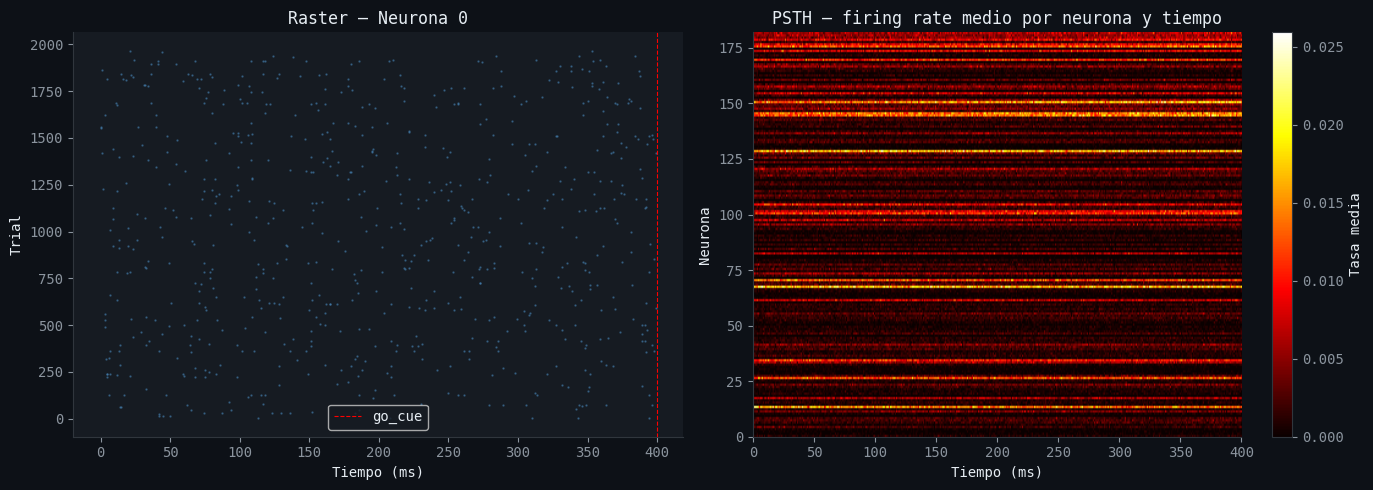

In [ ]:
#@title 1.3 Tensor binario

#Entrada a training
X = np.zeros((N_TRIALS, N_BINS, N_NEURONS), dtype=np.float32)

for t, i in enumerate(valid_idx):
  #Ventana de 400ms anterior al go_cue
    t_start = go_cue[i] - 0.400
    t_end   = go_cue[i]

  #Obtener todos los spikes en ese rango
    for k in range(N_NEURONS):
       #Solo spikes dentro del rango
        spikes_k         = neuron_spikes[k]
        mask             = (spikes_k >= t_start) & (spikes_k < t_end)
        spikes_in_window = spikes_k[mask]

       #Si no hay spikes detectados, continuar a la siguiente
        if len(spikes_in_window) == 0:
            continue

       # Convertir timestamps absolutos → índices de bin relativos a t_start
        bin_indices = ((spikes_in_window - t_start) / BIN_SIZE).astype(int)
        bin_indices = np.clip(bin_indices, 0, N_BINS - 1)

      # Marcar como 1 los bins donde hubo spike
        X[t, bin_indices, k] = 1.0

print(f"Shape tensor binario : {X.shape}")
print(f"Densidad de spikes   : {X.mean()*100:.3f}%")
print(f"Total spikes en X    : {int(X.sum())}")

print("\n")

#Representación
# ── 1. Raster plot: Actividad de una neurona en el tiempo ─────────────────────────
NEURONA = 0
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
spike_times_raster = np.where(X[:, :, NEURONA] == 1)
ax.scatter(spike_times_raster[1], spike_times_raster[0],
           s=0.5, color='steelblue', alpha=0.5)
ax.set_xlabel("Tiempo (ms)")
ax.set_ylabel("Trial")
ax.set_title(f"Raster — Neurona {NEURONA}")
ax.axvline(400, color='red', lw=0.8, ls='--', label='go_cue')
ax.legend()

# ── 2. PSTH: firing rate promedio por neurona ─────────────────────────────
ax = axes[1]
psth = X.mean(axis=0)  # (400, 182) — promedio sobre trials
im   = ax.imshow(psth.T, aspect='auto', origin='lower',
                 extent=[0, 400, 0, 182], cmap='hot')
ax.set_xlabel("Tiempo (ms)")
ax.set_ylabel("Neurona")
ax.set_title("PSTH — firing rate medio por neurona y tiempo")
plt.colorbar(im, ax=ax, label='Tasa media')

plt.tight_layout()
plt.show()


In [ ]:
#@title 1.4 Filtro Gaussiano

#Filtrado
X_smooth = gaussian_filter1d(X, sigma=10, axis=1, mode='constant', cval=0.0)

#Resultados
print(f"Shape tensor suavizado : {X_smooth.shape}")
print(f"Valor mínimo           : {X_smooth.min():.6f}")
print(f"Valor máximo           : {X_smooth.max():.6f}")
print(f"Valor medio            : {X_smooth.mean():.6f}")



Shape tensor suavizado : (1967, 400, 182)
Valor mínimo           : 0.000000
Valor máximo           : 0.273878
Valor medio            : 0.002624


Trial más activo  : 443
Neurona más activa: 67


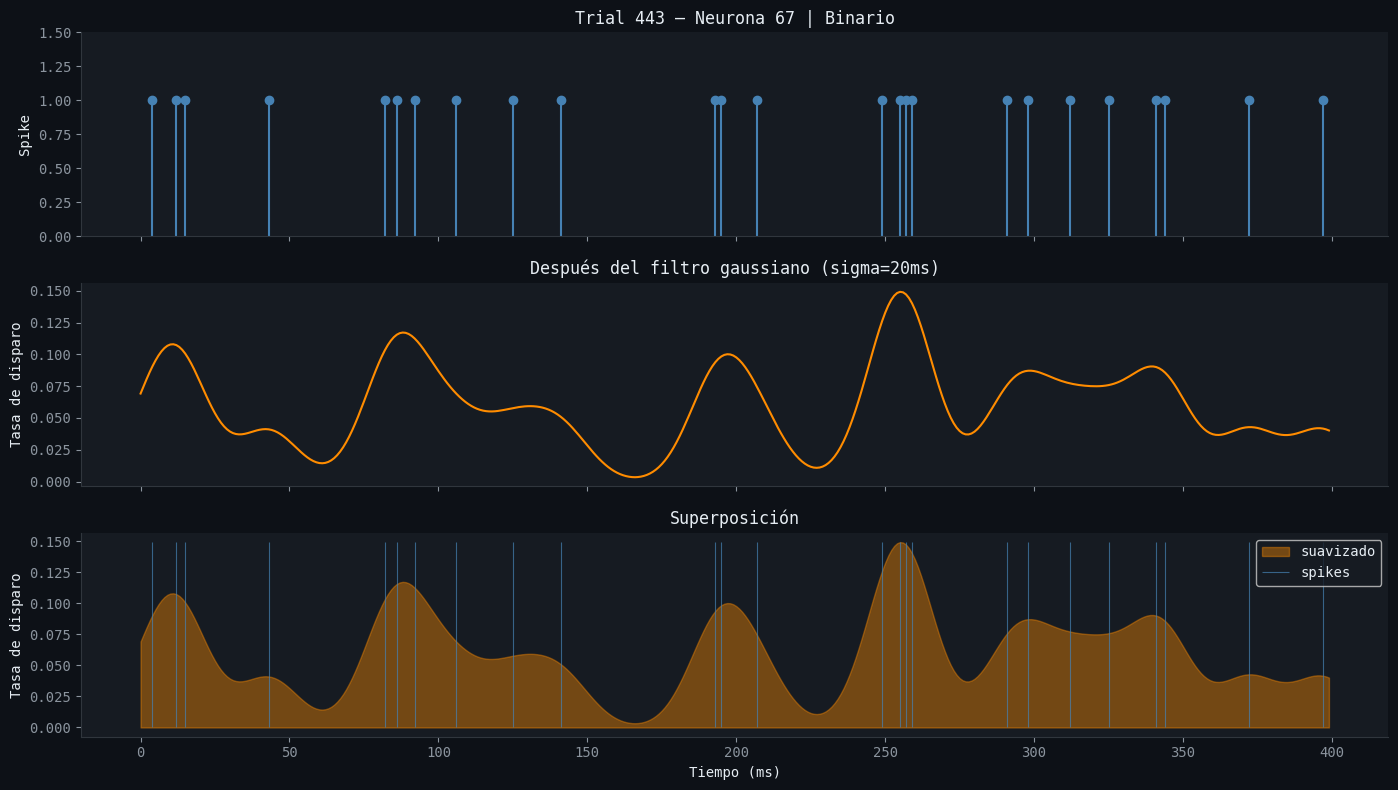

In [ ]:
#@title 1.5 Representación del filtro
#Encontrar neurona con más actividad
actividad   = X.sum(axis=1)                                                # (1967, 182)
trial_idx, neurona_idx = np.unravel_index(actividad.argmax(), actividad.shape)
print(f"Trial más activo  : {trial_idx}")
print(f"Neurona más activa: {neurona_idx}")

#Parámetros
TRIAL   = trial_idx
NEURONA = neurona_idx
spike_positions = np.where(X[TRIAL, :, NEURONA])[0]  # índices donde hay spike

#Plotting
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# 1. Binario
axes[0].stem(spike_positions,
             np.ones(len(spike_positions)),  # len() devuelve int
             linefmt='steelblue', markerfmt='o', basefmt=' ')
axes[0].set_ylabel("Spike")
axes[0].set_title(f"Trial {TRIAL} — Neurona {NEURONA} | Binario")
axes[0].set_ylim(0, 1.5)

# 2. Suavizado
axes[1].plot(X_smooth[TRIAL, :, NEURONA], color='darkorange', lw=1.5)
axes[1].set_ylabel("Tasa de disparo")
axes[1].set_title("Después del filtro gaussiano (sigma=20ms)")

# 3. Superposición
axes[2].fill_between(range(400), X_smooth[TRIAL, :, NEURONA],
                     color='darkorange', alpha=0.4, label='suavizado')
axes[2].vlines(spike_positions, 0,
               X_smooth[TRIAL, :, NEURONA].max(),
               color='steelblue', alpha=0.7, lw=0.8, label='spikes')
axes[2].set_xlabel("Tiempo (ms)")
axes[2].set_ylabel("Tasa de disparo")
axes[2].set_title("Superposición")
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
#@title 1.6 Extracción de clases

#Data
cursor_ts    = f_data['processing/behavior/cursor_pos/timestamps'][()]
cursor_pos   = f_data['processing/behavior/cursor_pos/data'][()]

# ── Calcular ángulo por trial ──────────────────────────────────────────────
# Ventana: 500ms después de move_onset = 50 muestras a 100Hz
WINDOW_SAMPLES = 50

angles_deg = []
for i in valid_idx:
    idx_start = np.searchsorted(cursor_ts, move_onset[i]) #Sincronizar tiempo de inicio
    idx_end   = idx_start + WINDOW_SAMPLES

    # Verificar que no nos salimos del array
    if idx_end >= len(cursor_pos):
        angles_deg.append(np.nan)
        continue

    hand_start = cursor_pos[idx_start]
    hand_end   = cursor_pos[idx_end]

    dx = hand_end[0] - hand_start[0]
    dy = hand_end[1] - hand_start[1]
    angles_deg.append(np.degrees(np.arctan2(dy, dx)))

angles_deg = np.array(angles_deg)

print(f"Ángulos calculados : {len(angles_deg)}")
print(f"NaN encontrados    : {np.isnan(angles_deg).sum()}")
print("\n")

# Descartar NaN (trials al borde del array)
valid_mask = ~np.isnan(angles_deg)
angles_deg = angles_deg[valid_mask]

#Asignar a 8 clases
bin_edges  = np.array([-180, -157.5, -112.5, -67.5, -22.5, 22.5, 67.5, 112.5, 157.5, 180])

direction_names = {
    0: 'Clase 4  (±180°)',
    1: 'Clase 5  (-135°)',
    2: 'Clase 6  (-90°)',
    3: 'Clase 7  (-45°)',
    4: 'Clase 0  (0°)',
    5: 'Clase 1  (45°)',
    6: 'Clase 2  (90°)',
    7: 'Clase 3  (135°)'
}

angles_clipped = np.clip(angles_deg, -179.99, 179.99)
bin_idx        = np.digitize(angles_clipped, bin_edges[1:-1]) % 8

# Presentar distribución
counts = Counter(bin_idx)
total  = len(bin_idx)

print(f"{'Clase':>6}  {'Dirección':<20}  {'N':>6}  {'%':>6}")
print("─" * 46)
for cls in range(8):
    n = counts.get(cls, 0)
    print(f"{cls:>6}  {direction_names[cls]:<20}  {n:>6}  {n/total*100:>5.1f}%")
print("─" * 46)
print(f"{'Total':<28}  {total:>6}  100.0%")


Ángulos calculados : 1967
NaN encontrados    : 0


 Clase  Dirección                  N       %
──────────────────────────────────────────────
     0  Clase 4  (±180°)          86    4.4%
     1  Clase 5  (-135°)         184    9.4%
     2  Clase 6  (-90°)          307   15.6%
     3  Clase 7  (-45°)           43    2.2%
     4  Clase 0  (0°)            338   17.2%
     5  Clase 1  (45°)           673   34.2%
     6  Clase 2  (90°)           195    9.9%
     7  Clase 3  (135°)          141    7.2%
──────────────────────────────────────────────
Total                           1967  100.0%


#2. Reducción de dimensionalidad

In [ ]:
#@title 2.1 Cálculo

# Aplanar modos trial y tiempo → (182, 1967*400) = (182, 786800)
# Esto expone la varianza de cada neurona a través de todos los trials y tiempos
X_unfold_neural = X_smooth.transpose(2, 0, 1).reshape(182, -1)
U, s, Vt = np.linalg.svd(X_unfold_neural, full_matrices=False)
explained = np.cumsum(s**2) / np.sum(s**2) # Varianza acumulada por cada neurona

#Resultados
r85 = np.searchsorted(explained, 0.85) + 1
r90 = np.searchsorted(explained, 0.90) + 1
r95 = np.searchsorted(explained, 0.95) + 1
print(f"R para 85%: {r85} | 90%: {r90} | 95%: {r95}")

R para 85%: 68 | 90%: 85 | 95%: 109


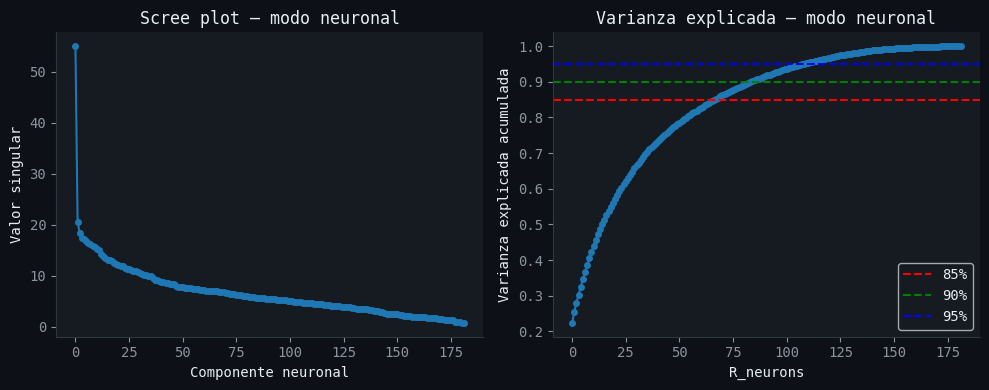


X_reduced shape: (1967, 400, 68)


In [ ]:
#@title 2.2 Representación

#Plotting
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(s, 'o-', markersize=4)
plt.xlabel('Componente neuronal')
plt.ylabel('Valor singular')
plt.title('Scree plot — modo neuronal')

plt.subplot(1, 2, 2)
plt.plot(explained, 'o-', markersize=4)
plt.axhline(y=0.85, color='r', linestyle='--', label='85%')
plt.axhline(y=0.90, color='g', linestyle='--', label='90%')
plt.axhline(y=0.95, color='b', linestyle='--', label='95%')
plt.xlabel('R_neurons')
plt.ylabel('Varianza explicada acumulada')
plt.legend()
plt.title('Varianza explicada — modo neuronal')
plt.tight_layout()
plt.show()

# Proyección Tucker
R_neurons = r85 #Se escoge el 85% de la varianza
C = U[:, :R_neurons] #Columnas ortogonales
X_reduced = X_smooth @ C

#Resultados
print(f"\nX_reduced shape: {X_reduced.shape}")

#3. Entrenamiento

In [ ]:
#@title 3.1 Separación de la data

#Variables iniciales
indices = np.arange(len(bin_idx))

# Split estratificado
#70% train
train_idx, temp_idx = train_test_split(indices, test_size=0.30,
                                       random_state=42, stratify=bin_idx)

#15% validación 15% test
val_idx, test_idx   = train_test_split(temp_idx, test_size=0.50,
                                       random_state=42, stratify=bin_idx[temp_idx])

# Normalización solo a train
mean = X_reduced[train_idx].mean(axis=(0, 1), keepdims=True)
std  = X_reduced[train_idx].std(axis=(0, 1), keepdims=True)

X_train = (X_reduced[train_idx] - mean) / (std + 1e-8)
X_val   = (X_reduced[val_idx]   - mean) / (std + 1e-8)
X_test  = (X_reduced[test_idx]  - mean) / (std + 1e-8)

y_train = bin_idx[train_idx]
y_val   = bin_idx[val_idx]
y_test  = bin_idx[test_idx]

# --- VERIFICACIÓN ---
angles = ['0°', '45°', '90°', '135°', '±180°', '-135°', '-90°', '-45°']

print(f"Total trials: {len(indices)} = {len(train_idx)} + {len(val_idx)} + {len(test_idx)}")
print(f"Proporciones: {len(train_idx)/len(indices):.2f} / {len(val_idx)/len(indices):.2f} / {len(test_idx)/len(indices):.2f}")
print()

# Distribución por clase en cada split — debe ser proporcional en los tres
print(f"{'Clase':<12} {'Total':>6} {'Train':>6} {'Val':>6} {'Test':>6}")
print("-" * 42)
for cls in range(8):
    n_total = (bin_idx == cls).sum()
    n_train = (y_train == cls).sum()
    n_val   = (y_val   == cls).sum()
    n_test  = (y_test  == cls).sum()
    print(f"{angles[cls]:<12} {n_total:>6} {n_train:>6} {n_val:>6} {n_test:>6}")

print()
# Verificar no hay solapamiento entre splits
assert len(np.intersect1d(train_idx, val_idx))  == 0, "FUGA: train y val comparten índices"
assert len(np.intersect1d(train_idx, test_idx)) == 0, "FUGA: train y test comparten índices"
assert len(np.intersect1d(val_idx,   test_idx)) == 0, "FUGA: val y test comparten índices"
print("Sin solapamiento entre splits: OK")

# Verificar normalización
print(f"\nX_train media: {X_train.mean():.4f} (esperado ≈ 0)")
print(f"X_train std:   {X_train.std():.4f}  (esperado ≈ 1)")
print(f"X_val media:   {X_val.mean():.4f}   (esperado ≈ 0, no exacto)")
print(f"X_test media:  {X_test.mean():.4f}  (esperado ≈ 0, no exacto)")

#Tamaño del resultado
print(f"\nX_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")

print(f"\ny_train shape: {y_train.shape}")
print(f"y_val shape:   {y_val.shape}")
print(f"y_test shape:  {y_test.shape}")

Total trials: 1967 = 1376 + 295 + 296
Proporciones: 0.70 / 0.15 / 0.15

Clase         Total  Train    Val   Test
------------------------------------------
0°               86     60     13     13
45°             184    129     27     28
90°             307    215     46     46
135°             43     30      7      6
±180°           338    236     51     51
-135°           673    471    101    101
-90°            195    136     29     30
-45°            141     99     21     21

Sin solapamiento entre splits: OK

X_train media: -0.0000 (esperado ≈ 0)
X_train std:   1.0002  (esperado ≈ 1)
X_val media:   0.0048   (esperado ≈ 0, no exacto)
X_test media:  0.0005  (esperado ≈ 0, no exacto)

X_train shape: (1376, 400, 68)
X_val shape:   (295, 400, 68)
X_test shape:  (296, 400, 68)

y_train shape: (1376,)
y_val shape:   (295,)
y_test shape:  (296,)


In [ ]:
#@title 3.2 Tratamiento de desbalance
#Cost-sensitive balance
weights = compute_class_weight(class_weight='balanced',
                               classes=np.arange(8),
                               y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float32)
print(f"\nClass weights: {np.round(weights, 3)}")


Class weights: [2.867 1.333 0.8   5.733 0.729 0.365 1.265 1.737]


In [ ]:
#@title 3.3 Hiperparámetros
# --- HIPERPARÁMETROS ---
LSTM1_UNITS   = 64
LSTM2_UNITS   = 32
DROPOUT1_RATE = 0.3
DROPOUT2_RATE = 0.4
L2_REG        = 0.001
LEARNING_RATE = 0.0001
EPOCHS        = 200
BATCH_SIZE    = 64
PATIENCE_ES   = 20
PATIENCE_LR   = 7

INPUT_SIZE = X_train.shape[2]  # R_neurons
NUM_CLASSES = 8

print(f"Input size (R_neurons): {INPUT_SIZE}")
print(f"LSTM: {LSTM1_UNITS} → {LSTM2_UNITS} → {NUM_CLASSES}")

Input size (R_neurons): 68
LSTM: 64 → 32 → 8


In [ ]:
#@title 3.4 Arquitectura
class MotorLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm1 = nn.LSTM(input_size=INPUT_SIZE, hidden_size=LSTM1_UNITS,
                             batch_first=True)
        self.drop1 = nn.Dropout(DROPOUT1_RATE)
        self.lstm2 = nn.LSTM(input_size=LSTM1_UNITS, hidden_size=LSTM2_UNITS,
                             batch_first=True)
        self.drop2 = nn.Dropout(DROPOUT2_RATE)
        self.fc    = nn.Linear(LSTM2_UNITS, NUM_CLASSES)

    def forward(self, x):
        x, _ = self.lstm1(x)         # (batch, 400, LSTM1_UNITS)
        x = self.drop1(x)
        x, _ = self.lstm2(x)         # (batch, 400, LSTM2_UNITS)
        x = self.drop2(x)
        x = x[:, -1, :]              # último timestep (batch, LSTM2_UNITS)
        return self.fc(x)            # (batch, 8)

In [ ]:
#@title 3.5 Procedimientos
# --- DATALOADERS ---
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val,   dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),
                          batch_size=BATCH_SIZE, shuffle=False)

# --- MODELO, LOSS, OPTIMIZER ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model     = MotorLSTM().to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE,
                             weight_decay=L2_REG)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                        patience=PATIENCE_LR,
                                                        factor=0.5)

print(f"\nModelo en: {device}")
print(f"Parámetros totales: {sum(p.numel() for p in model.parameters()):,}")


Modelo en: cpu
Parámetros totales: 47,112


In [ ]:
#@title 3.6 Entrenamiento
# --- TRAINING LOOP ---
best_val_loss = float('inf')
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    # Training
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        train_loss  += loss.item() * len(y_batch)
        preds        = logits.argmax(dim=1)
        train_correct += (preds == y_batch).sum().item()
        train_total  += len(y_batch)

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)

            val_loss    += loss.item() * len(y_batch)
            preds        = logits.argmax(dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total   += len(y_batch)

    # Métricas de época
    t_loss = train_loss / train_total
    v_loss = val_loss   / val_total
    t_acc  = train_correct / train_total
    v_acc  = val_correct   / val_total

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    scheduler.step(v_loss)

    # Early stopping
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | "
              f"Train loss: {t_loss:.4f} acc: {t_acc:.3f} | "
              f"Val loss: {v_loss:.4f} acc: {v_acc:.3f} | "
              f"Patience: {patience_counter}/{PATIENCE_ES}")

    if patience_counter >= PATIENCE_ES:
        print(f"\nEarly stopping en época {epoch+1}")
        break

# Cargar mejor modelo
model.load_state_dict(torch.load('best_model.pt'))
print(f"\nMejor val loss: {best_val_loss:.4f}")



Epoch  10 | Train loss: 2.0669 acc: 0.244 | Val loss: 2.0810 acc: 0.275 | Patience: 0/20
Epoch  20 | Train loss: 2.0371 acc: 0.266 | Val loss: 2.0698 acc: 0.288 | Patience: 0/20
Epoch  30 | Train loss: 1.9442 acc: 0.292 | Val loss: 2.0471 acc: 0.258 | Patience: 0/20
Epoch  40 | Train loss: 1.6906 acc: 0.320 | Val loss: 2.0228 acc: 0.214 | Patience: 0/20
Epoch  50 | Train loss: 1.4269 acc: 0.375 | Val loss: 2.0621 acc: 0.247 | Patience: 10/20
Epoch  60 | Train loss: 1.3291 acc: 0.402 | Val loss: 2.0837 acc: 0.264 | Patience: 20/20

Early stopping en época 60

Mejor val loss: 2.0228


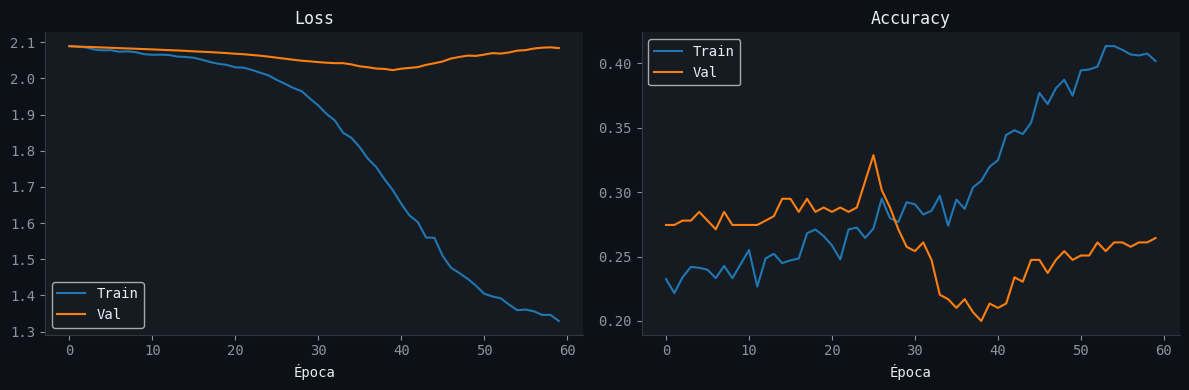

In [ ]:
#@title 3.7 Curvas de entrenamiento

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'],   label='Val')
ax1.set_title('Loss')
ax1.set_xlabel('Época')
ax1.legend()

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'],   label='Val')
ax2.set_title('Accuracy')
ax2.set_xlabel('Época')
ax2.legend()

plt.tight_layout()
plt.show()



              precision    recall  f1-score   support

          0°       0.15      0.46      0.22        13
         45°       0.00      0.00      0.00        28
         90°       0.25      0.39      0.31        46
        135°       0.03      0.17      0.05         6
       ±180°       0.25      0.59      0.36        51
       -135°       0.33      0.02      0.04       101
        -90°       0.25      0.13      0.17        30
        -45°       0.00      0.00      0.00        21

    accuracy                           0.21       296
   macro avg       0.16      0.22      0.14       296
weighted avg       0.23      0.21      0.15       296



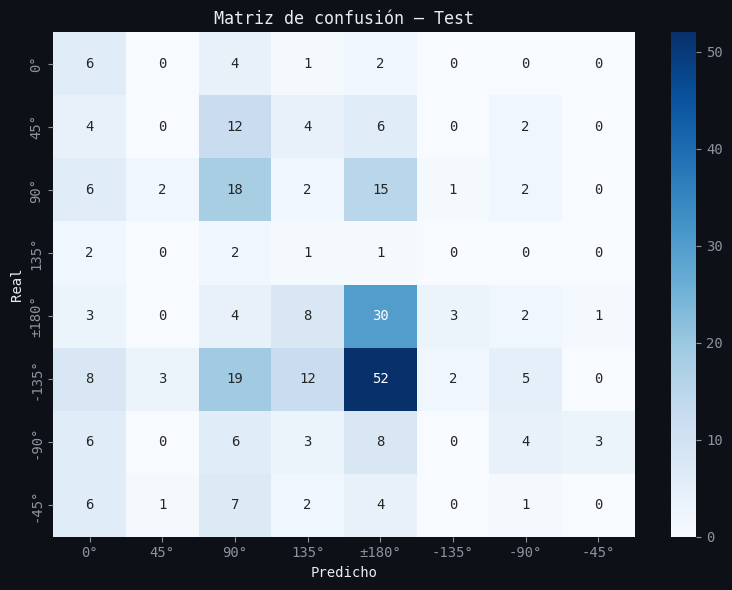

In [ ]:
#@title 3.8  Test
# --- EVALUACIÓN FINAL EN TEST ---
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in DataLoader(TensorDataset(X_test_t, y_test_t),
                                        batch_size=BATCH_SIZE):
        X_batch = X_batch.to(device)
        preds   = model(X_batch).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

angles = ['0°', '45°', '90°', '135°', '±180°', '-135°', '-90°', '-45°']
print(classification_report(all_labels, all_preds, target_names=angles))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=angles, yticklabels=angles,
            cmap='Blues')
plt.title('Matriz de confusión — Test')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

In [ ]:
print(f"class_weights device: {class_weights.device}")
print(f"model device: {next(model.parameters()).device}")

class_weights device: cpu
model device: cpu
